# Perceptron

El **Perceptrón** es un algoritmo de aprendizaje automático supervisado utilizado para clasificación binaria. Es el modelo de red neuronal artificial más simple, consistente en una única neurona que recibe múltiples entradas, aplica pesos a cada una, y produce una salida binaria basada en una función de activación.

<img src="../images/perceptron.png">

### Componentes principales

- **Entradas (inputs)**: Variables de características $x_1, x_2, ..., x_n$. Son los datos o características que recibe (ej. el tamaño de una célula o el color de un píxel).

- **Pesos (weights)**: Parámetros $w_1, w_2, ..., w_n$ que se ajustan durante el entrenamiento. Determinan qué tan importante es cada entrada. Si un peso es alto, esa entrada influye mucho en el resultado.

- **Sesgo (bias)**: Término $b$ que permite desplazar la función de decisión. Es un valor adicional que permite al modelo ajustar su umbral de decisión, independientemente de las entradas.

- **Suma Ponderada**: $\sum$ El perceptrón multiplica cada entrada por su peso y suma todo, incluyendo el sesgo.

- **Función de activación**: Típicamente una función escalón que produce salidas discretas (0 o 1)

### Ecuación matemática

La salida del perceptrón se calcula como:

$$\hat{y} = \begin{cases} 1 & \text{si } \sum_{i=1}^{n} w_i x_i + b > 0 \\ 0 & \text{en caso contrario} \end{cases}$$

### Características

- **Modelo lineal**: Puede separar datos únicamente si son linealmente separables

- **Entrenamiento**: Usa una regla de aprendizaje iterativa que ajusta pesos cuando comete errores

- **Limitaciones**: No puede resolver problemas no lineales (como XOR)

- **Base conceptual**: Es la base teórica para redes neuronales más complejas

<img src="../images/perceptron_img1.png">

## El Ciclo de Aprendizaje 🔄
Para aprender, el perceptrón sigue un proceso repetitivo:
- **Predicción**: Calcula una salida usando sus pesos actuales.

- **Cálculo del error**: Resta la predicción del valor real ($Valor\ Real - Predicción$).

- **Actualización**: Si hubo un error, ajusta los pesos para que la próxima vez la predicción sea más acertada.

## Parámetros
- **Pesos (w)**: Parámetros que multiplican cada entrada para dar importancia a cada característica. Se inicializan aleatoriamente y se ajustan durante el entrenamiento mediante la regla de aprendizaje.
  
- **Sesgo (b)**: Un término independiente que se suma al producto. Permite que la línea de decisión no pase necesariamente por el origen, brindando flexibilidad adicional al modelo.

- **Tasa de aprendizaje (α)**: Controla la magnitud de los ajustes de pesos durante el entrenamiento. Valores más altos aceleran el aprendizaje pero pueden causar inestabilidad; valores más bajos son más conservadores.

### Inicialización
- Los pesos se inicializan típicamente con pequeños valores aleatorios (ej: distribución uniforme o normal cercana a cero).
- El sesgo generalmente se inicializa en cero o con un pequeño valor aleatorio.

### Actualización durante el entrenamiento
Para cada ejemplo mal clasificado:
$$w_i := w_i + \alpha \cdot y \cdot x_i$$
$$b := b + \alpha \cdot y$$

Donde $y$ es la etiqueta verdadera (0 o 1) y $x_i$ es la característica de entrada.

Todo este proceso se resume en una ecuación simple:$$z = (x_1 \cdot w_1) + (x_2 \cdot w_2) + ... + (x_n \cdot w_n) + b$$Luego, el resultado $z$ pasa por la función de activación. En el perceptrón clásico, se usa una función de paso: si $z$ es mayor a 0, la salida es 1; de lo contrario, es 0.

### Tasa de aprendizaje
La **tasa de aprendizaje (learning rate, α)** es un hiperparámetro fundamental que controla la magnitud del ajuste de pesos durante cada iteración del entrenamiento.

Es un valor numérico (típicamente entre 0.001 y 1) que multiplica el cambio calculado en los pesos. Determina **qué tan rápido o lento** el modelo "aprende" de los errores.

La tasa de aprendizaje es como el tamaño de los pasos que da el modelo hacia la solución.

- Si los pasos **son muy grandes**, el modelo podría "saltarse" la solución óptima y rebotar de un lado a otro.

- Si los pasos **son muy pequeños**, el modelo aprenderá con una precisión asombrosa, pero tardará muchísimo tiempo en llegar a la meta.

Para ver si la lógica del ajuste queda clara, imaginemos este escenario: el perceptrón hace una predicción y el resultado es exactamente igual al valor real (el error es cero).

#### Impacto en el entrenamiento

| Tasa de aprendizaje | Efecto |
|---|---|
| **Muy alta** (ej: 1.0) | Convergencia rápida pero inestable; puede oscilar o diverger sin encontrar la solución óptima |
| **Óptima** (ej: 0.01-0.1) | Balance entre velocidad de convergencia y estabilidad; encuentra la solución de manera eficiente |
| **Muy baja** (ej: 0.0001) | Convergencia lenta y requiere más iteraciones; computacionalmente costoso |

#### Cómo se determina

1. **Prueba y error**: Comenzar con un valor típico (ej: 0.1) y ajustar según los resultados
2. **Observar el comportamiento**: 
    - Si el costo aumenta o oscila → reducir α
    - Si el costo disminuye lentamente → aumentar α
3. **Métodos automáticos**: Utilizar optimizadores adaptativos como:
    - **Adam**: Ajusta automáticamente la tasa de aprendizaje por parámetro
    - **RMSprop**: Escala la tasa según el historial de gradientes
    - **Gradient Descent con momentum**: Mejora la convergencia

4. **Técnicas avanzadas**:
    - **Learning rate scheduling**: Reducir α gradualmente durante el entrenamiento
    - **Grid search o Random search**: Probar múltiples valores sistemáticamente

## El mundo ideal: Datos linealmente separables
Un problema es linealmente separable cuando puedes dibujar una única línea recta que deje todos los puntos de la "Clase A" a un lado y todos los de la "Clase B" al otro. En estos casos, el perceptrón es infalible: se ha demostrado que, si existe una solución, el algoritmo la encontrará tarde o temprano.

**El choque con la realidad: El límite del Perceptrón**

El gran problema surge cuando los datos están mezclados de tal forma que ninguna línea recta puede dividirlos sin cometer errores. El ejemplo histórico más famoso es el problema de la compuerta lógica XOR.

En XOR, las clases están distribuidas en "diagonal", lo que hace imposible separarlas con una sola línea.

Cuando el perceptrón se enfrenta a esto, sus pesos nunca dejan de cambiar porque intenta encontrar una línea que simplemente no existe.

**Cuando la realidad es compleja**

Para resolver problemas que no son lineales (como reconocer rostros o entender el lenguaje), un solo perceptrón no es suficiente. La solución que dio origen al **Deep Learning** fue unir muchos perceptrones en capas, creando el **Perceptrón Multicapa** (MLP). Al conectarlos, las líneas rectas de cada uno se combinan para formar curvas y fronteras de decisión mucho más complejas.

## Programar un Perceptron en scikit-learn

Programar un perceptrón en Python es muy directo gracias a scikit-learn. Esta biblioteca ya tiene una clase optimizada llamada Perceptron dentro de su módulo de modelos lineales.

Aquí tienes los hiperparámetros más comunes que podemos ajustar antes de empezar el entrenamiento:

| Hiperparámetro | Nombre en el código | Qué hace |
|---|---|---|
| Tasa de aprendizaje | eta0 | Determina el tamaño del paso al actualizar los pesos. |
| Épocas | max_iter | El número máximo de veces que el modelo revisará todo el conjunto de datos. |
| Tolerancia | tol | El margen de mejora mínimo; si el error no baja de aquí, el entrenamiento se detiene. |
| Estado Aleatorio | random_state | Asegura que los resultados sean los mismos cada vez que corras el código. |

**Ejemplo de implementación**



In [4]:
# dataset IRIS con Perceptrón
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Cargamos los datos
iris = load_iris()
X = iris.data[:, [2, 3]] # Usamos largo y ancho del pétalo
y = (iris.target == 0).astype(int) # 1 si es Setosa, 0 si no lo es

# 2. Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Escalado de datos (muy importante para el perceptrón)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# 4. Creamos y configuramos el modelo con sus hiperparámetros
ppn = Perceptron(eta0=0.1, max_iter=100, tol=1e-3, random_state=42)

# 5. ¡A entrenar!
ppn.fit(X_train_std, y_train)

# 6. Predicción
predicciones = ppn.predict(X_test_std)
print(f"Precisión del modelo: {ppn.score(X_test_std, y_test):.2f}")

Precisión del modelo: 1.00


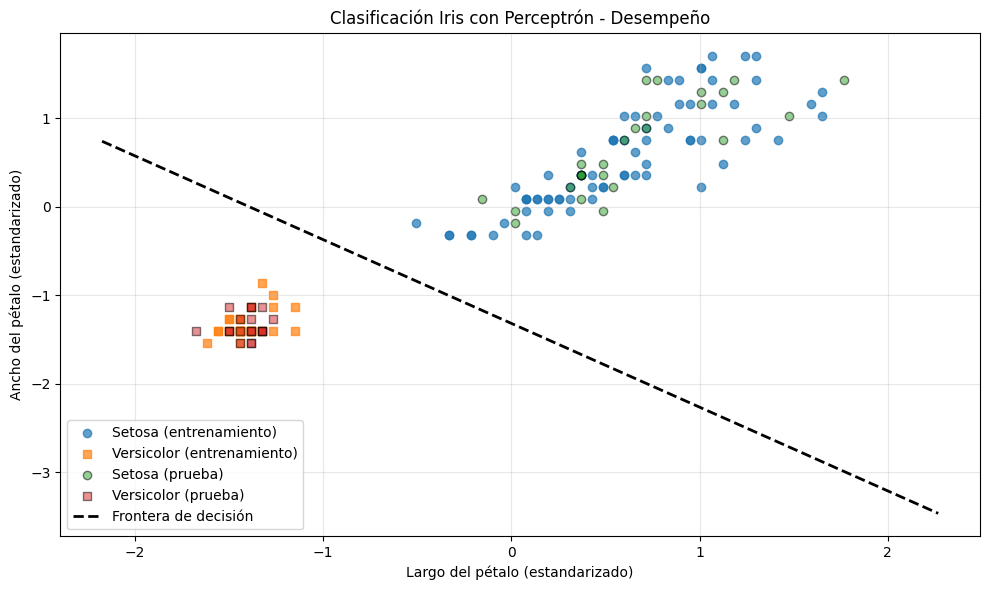

Precisión en entrenamiento: 1.0000
Precisión en prueba: 1.0000


In [5]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train_std[y_train == 0, 0], X_train_std[y_train == 0, 1], 
            label='Setosa (entrenamiento)', alpha=0.7, marker='o')
plt.scatter(X_train_std[y_train == 1, 0], X_train_std[y_train == 1, 1], 
            label='Versicolor (entrenamiento)', alpha=0.7, marker='s')
plt.scatter(X_test_std[y_test == 0, 0], X_test_std[y_test == 0, 1], 
            label='Setosa (prueba)', alpha=0.5, marker='o', edgecolors='black')
plt.scatter(X_test_std[y_test == 1, 0], X_test_std[y_test == 1, 1], 
            label='Versicolor (prueba)', alpha=0.5, marker='s', edgecolors='black')

# Dibuja la línea de decisión
x_min, x_max = X_test_std[:, 0].min() - 0.5, X_test_std[:, 0].max() + 0.5
xx = np.linspace(x_min, x_max, 100)
w = ppn.coef_[0]
b = ppn.intercept_[0]
yy = -(w[0] * xx + b) / w[1]
plt.plot(xx, yy, 'k--', linewidth=2, label='Frontera de decisión')

plt.xlabel('Largo del pétalo (estandarizado)')
plt.ylabel('Ancho del pétalo (estandarizado)')
plt.title('Clasificación Iris con Perceptrón - Desempeño')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('perceptron_evaluation.png', dpi=300)
plt.show()

print(f"Precisión en entrenamiento: {ppn.score(X_train_std, y_train):.4f}")
print(f"Precisión en prueba: {ppn.score(X_test_std, y_test):.4f}")

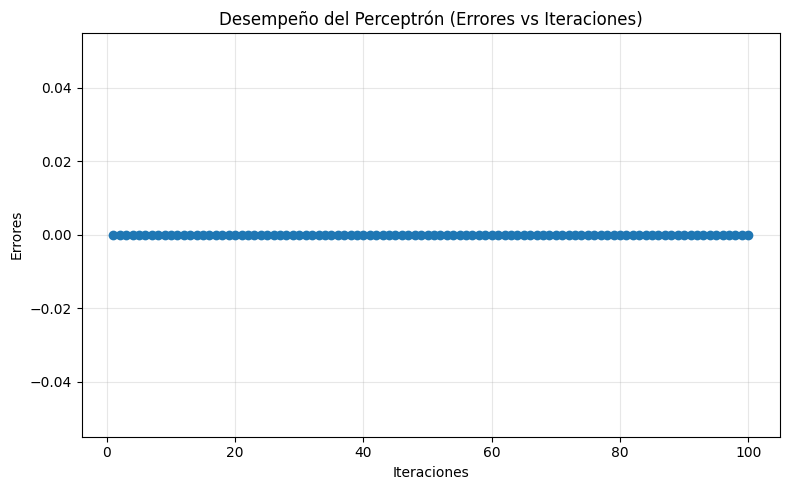

In [6]:
# Gráfico de desempeño del perceptrón: errores vs iteraciones
classes = np.unique(y_train)
errores = []
iter = 100
ppn_perf = Perceptron(eta0=0.1, max_iter=iter, tol=None, random_state=42, warm_start=True)

for _ in range(iter):
    ppn_perf.partial_fit(X_train_std, y_train, classes=classes)
    pred = ppn_perf.predict(X_train_std)
    errores.append((pred != y_train).sum())

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(errores) + 1), errores, marker='o')
plt.xlabel('Iteraciones')
plt.ylabel('Errores')
plt.title('Desempeño del Perceptrón (Errores vs Iteraciones)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('perceptron_evaluation.png', dpi=300)
plt.show()



¡Qué buena visualización! 📈 Este gráfico es fundamental para entender cómo "aprende" realmente el modelo.

### ¿Qué estamos viendo? 🔍

El gráfico muestra la relación entre las **Épocas** (eje X) y el **Número de errores o actualizaciones** (eje Y) durante el entrenamiento:

* **Épocas**: Representan cuántas veces el perceptrón ha revisado el conjunto completo de datos.
* **Actualizaciones (Errores)**: Cada vez que el perceptrón clasifica mal un dato, el algoritmo ajusta sus **pesos**. Por eso, el número de actualizaciones es un reflejo directo de cuántos errores cometió en esa vuelta.
* **Convergencia**: En el gráfico, vemos cómo los errores caen rápidamente hasta llegar a **cero**. Esto nos indica que el modelo ha encontrado una línea perfecta para separar las clases (en este caso, las flores Iris).

### El papel de los hiperparámetros ⚙️

Si cambiáramos la **tasa de aprendizaje** (), esta curva cambiaría de forma:

* Una tasa muy alta podría hacer que la curva suba y baje erráticamente (rebotando).
* Una tasa muy baja haría que la curva baje de forma mucho más lenta, necesitando más épocas para llegar a cero.

Observando el gráfico, el modelo llega a cero errores muy rápido (en la segunda época). 

Análisis del gráfico 📈

En el gráfico resultante, observarás que la línea de errores cae rápidamente hacia el valor 0.
- Convergencia: Cuando la curva llega a cero y se mantiene plana, significa que el perceptrón encontró los pesos ($w$) y el sesgo ($b$) ideales para trazar una línea que separa perfectamente ambos grupos.

- Velocidad: Si los errores bajan a cero en muy pocas épocas, indica que el problema es "fácil" o muy claramente linealmente separable.

## Perceptrón con *Breast Cancer* (scikit-learn)

**Objetivo:** entrenar un Perceptrón con el dataset *Breast Cancer*, visualizar **errores vs epoch** y analizar métricas (MAE, R², accuracy, precision, recall, F1).

### Pasos del flujo
1. Cargar el dataset `load_breast_cancer`.
2. Dividir en train/test y **escalar** las variables.
3. Entrenar un `Perceptron` con `warm_start=True` para acumular errores por época.
4. Graficar **Errores vs Epoch**.
5. Evaluar con:
    - **Accuracy**
    - **Precision / Recall / F1**
    - **MAE** (sobre predicciones binarias)
    - **R²** (como indicador adicional)

### Interpretación esperada
- El gráfico de **errores vs epoch** debería mostrar una disminución sostenida si el modelo converge.
- **MAE** cercano a 0 indica pocas predicciones incorrectas.
- **R²** no es ideal para clasificación, pero se reporta como métrica complementaria.
- **Precision/Recall/F1** permiten evaluar el balance entre falsos positivos y falsos negativos.

### Sugerencias
- Ajustar `eta0`, `max_iter` y `tol` si el error no converge.
- Probar `class_weight='balanced'` si hay desbalance de clases.

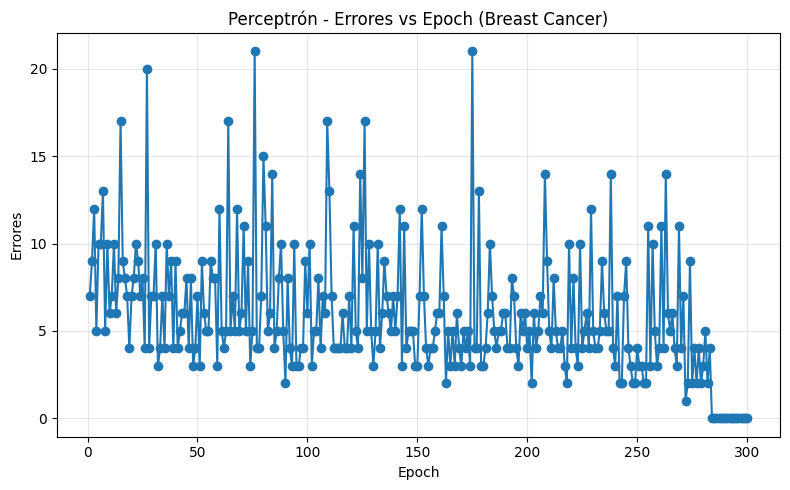

{'accuracy': 0.9473684210526315,
 'precision': 0.9711538461538461,
 'recall': 0.9439252336448598,
 'f1': 0.957345971563981,
 'mae': 0.05263157894736842,
 'r2': 0.7752628504672897}

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    r2_score,
)

# 1. Cargar datos
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

# 2. Train/test + escalado
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer
)
sc_c = StandardScaler()
X_train_c_std = sc_c.fit_transform(X_train_c)
X_test_c_std = sc_c.transform(X_test_c)

# 3. Entrenar con warm_start para errores por época
epochs_c = 300
learning_rate_c = 1
iteraciones_c = 100
ppn_c = Perceptron(eta0=learning_rate_c, max_iter=epochs_c, tol=None, warm_start=True, random_state=42)
error_history_c = []
classes_c = np.unique(y_train_c)

for _ in range(epochs_c):
    ppn_c.partial_fit(X_train_c_std, y_train_c, classes=classes_c)
    y_train_pred_c = ppn_c.predict(X_train_c_std)
    error_history_c.append((y_train_pred_c != y_train_c).sum())

# 4. Errores vs epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_c + 1), error_history_c, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Errores")
plt.title("Perceptrón - Errores vs Epoch (Breast Cancer)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Métricas
y_test_pred_c = ppn_c.predict(X_test_c_std)
metrics_c = {
    "accuracy": accuracy_score(y_test_c, y_test_pred_c),
    "precision": precision_score(y_test_c, y_test_pred_c),
    "recall": recall_score(y_test_c, y_test_pred_c),
    "f1": f1_score(y_test_c, y_test_pred_c),
    "mae": mean_absolute_error(y_test_c, y_test_pred_c),
    "r2": r2_score(y_test_c, y_test_pred_c),
}
metrics_c